In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
from spatial_manifolds.brainrender_helper import *

warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [2]:
mouse = 0
day = 0
session_type = 'OF1'
sorter = 'kilosort4'
storage = Path('/Users/harryclark/Downloads/COHORT12/')

alpha = 0.001
n_jobs = 8
n_shuffles = 100
seed = 1
class Args:
    def __init__(self,mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed):
        self.mouse = mouse
        self.day = day
        self.session_type = session_type
        self.sorter = sorter
        self.storage = storage
        self.alpha = alpha
        self.n_jobs = n_jobs
        self.n_shuffles = n_shuffles
        self.seed = seed
args = Args(mouse,day,session_type,sorter,storage,alpha,n_jobs,n_shuffles,seed)

In [3]:
def load_cluster_locations(clusters, cells):
    for column in ['coord_SCs_x', 'coord_SCs_y', 'coord_SCs_z', 'coord_probe_x', 'coord_probe_y','brain_region']:
        vals = []
        for id in cells.cluster_id:
            vals.append(clusters[column][id])
        cells[column] = vals
    return cells

In [4]:
args.session_type = 'OF1'

# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()
all_by_anatomy = pd.DataFrame()

for session_path in sorted(
    list(args.storage.glob(f'*/*/{args.session_type}/*{args.session_type}_beh.nwb'))
): 
    print(session_path)
    args.mouse = int(session_path.parent.parent.parent.name[1:])
    args.day = int(session_path.parent.parent.name[1:])
    mouse_day = f'M{args.mouse}D{args.day}'
    mouse = args.mouse
    day = args.day
    
    [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, percentile_threshold=95, 
                                                              disqualifying_brain_areas_for_grid_cells=disqualifying_brain_areas_for_grid_cells)
    [_, _, _, _, _, _, _, all_a] = cell_classification_anatomy(mouse, day)

    _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

    gcs = load_cluster_locations(clusters_VR, cells=gcs)
    ngs = load_cluster_locations(clusters_VR, cells=ngs)
    ns = load_cluster_locations(clusters_VR, cells=ns)
    sc = load_cluster_locations(clusters_VR, cells=sc)
    ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
    all = load_cluster_locations(clusters_VR, cells=all)
    all_a = load_cluster_locations(clusters_VR, cells=all_a)

    gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
    ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
    ns_ = pd.concat([ns_, ns], ignore_index=True)
    sc_ = pd.concat([sc_, sc], ignore_index=True)
    ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
    all_ = pd.concat([all_, all], ignore_index=True)
    all_by_anatomy = pd.concat([all_by_anatomy, all_a], ignore_index=True)

    print(f'there are this many cells at the moment, {len(all_by_anatomy)}')

/Users/harryclark/Downloads/COHORT12/M20/D14/OF1/sub-20_day-14_ses-OF1_beh.nwb
20 14
optimal travel lag is 0.2502502502502537 cm based on kde of travel at max spatial information
optimal travel lag is 0.2502502502502537 cm
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
there are 204 MEC cells
there are 0 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 204 all cells
there are this many cells at the moment, 204
/Users/harryclark/Downloads/COHORT12/M20/D15/OF1/sub-20_day-15_ses-OF1_beh.nwb
20 15
optimal travel lag is 3.753753753753756 cm based on kde of travel at max spatial information
optimal travel lag is 3.753753753753756 cm
th

In [12]:
# Swap probe_x locations for mouse 21 in all_by_anatomy
swap_dict = {
    0: 782,
    32: 750,
    250: 532,
    282: 500,
    500: 282,
    532: 250,
    750: 32,
    782: 0
}

mask = all_a['mouse'] == 21
all_a.loc[mask, 'probe_x'] = all_a.loc[mask, 'probe_x'].map(lambda x: swap_dict.get(x, x))

Plotting for mouse 20
unique brain regions: ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'VISp2/3' 'VISl2/3' 'VISpl2/3' 'VISl1'
 'VISp1' 'VISpl5']


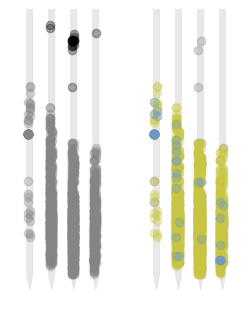

Plotting for mouse 21
unique brain regions: ['ENTm2' 'ENTm1' 'ENTm3' 'ENTm5' 'ENTm6' 'ENTl6a' 'VISpor6a' 'VISpl6a'
 'VISpor5' 'VISpl5' 'VISl5' 'VISl4' 'VISl2/3' 'HPF' 'dhc' 'or' 'VISpor6b'
 'VISl6a' 'ec' 'VISpl6b' 'VISp6a' 'VISp5' 'VISpl4' 'VISpl2/3' 'VISl1']


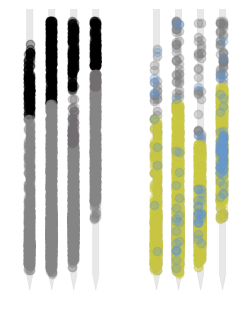

Plotting for mouse 25
unique brain regions: ['ENTm2' 'ENTm1' 'ENTm3' 'PAR' 'VISpl5' 'ENTm5' 'VISp5' 'VISpl4'
 'VISpl2/3' 'VISp2/3' 'VISpl1' 'VISl1' 'VISp4']


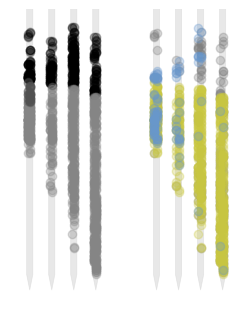

Plotting for mouse 26
unique brain regions: ['ENTm1' 'ENTm2' 'ENTm3' 'VISpl5' 'VISpl4' 'ENTm5' 'VISpor5' 'PAR'
 'VISpl6a' 'VISp5' 'VISp4' 'VISl4' 'VISl2/3' 'VISpl2/3' 'VISp2/3']


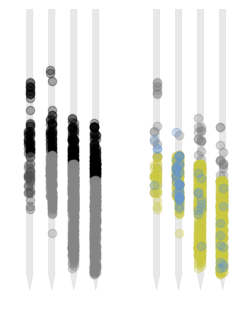

Plotting for mouse 27
unique brain regions: ['CUL4, 5' 'ENTm2' 'PAR' 'ENTm1' 'VISpl5' 'VISpl6a' 'APr' 'RSPd6a' 'ENTm3'
 'ENTm5']


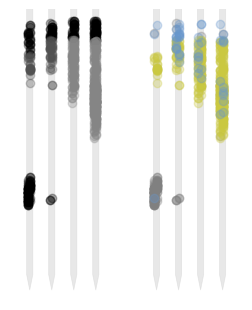

Plotting for mouse 28
unique brain regions: ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'VISpl6a' 'VISpl5' 'APr' 'VISp5'
 'VISp4' 'VISp2/3' 'VISl5' 'VISpl4' 'VISl4' 'VISl2/3' 'VISpor5' 'VISl1'
 'VISp1' 'VISp6a']


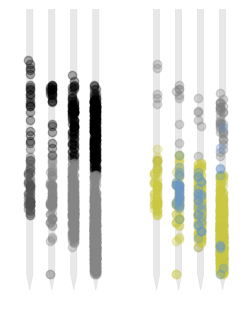

Plotting for mouse 29
unique brain regions: ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR' 'APr' 'VISpl6a' 'VISpl5' 'VISpl4'
 'VISp2/3' 'VISp1' 'VISl2/3' 'VISp5' 'VISp6a']


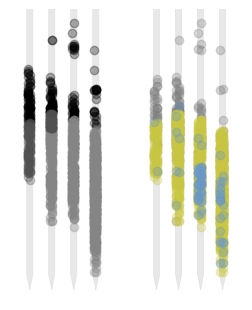

In [5]:
for mouse in [20,21,25,26,27,28,29]:
    print(f'Plotting for mouse {mouse}')
    print('unique brain regions:', all_[all_['mouse'] == mouse]['brain_region'].unique())
    mouse_all = all_[all_['mouse'] == mouse]
    mouse_vis = mouse_all[mouse_all['brain_region'].str.contains('VIS|APr')]
    mouse_ent = mouse_all[mouse_all['brain_region'].str.contains('ENT')]
    mouse_par = mouse_all[mouse_all['brain_region'].str.contains('PAR')]
    mouse_hpf = mouse_all[mouse_all['brain_region'].str.contains('HPF')]
    mouse_cere = mouse_all[mouse_all['brain_region'].str.contains('PFL|FL|SIM|root|mcp|CUL')]
    fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(3, 12), squeeze=False)
    plot_NP2_probe(ax[0,0], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
    ax[0,0].scatter(mouse_vis['probe_x'], mouse_vis['probe_y'], color="#000000", alpha=0.3)
    ax[0,0].scatter(mouse_ent['probe_x'], mouse_ent['probe_y'], color="#858585", alpha=0.3)
    ax[0,0].scatter(mouse_par['probe_x'], mouse_par['probe_y'], color="#515151", alpha=0.3)
    ax[0,0].scatter(mouse_cere['probe_x'], mouse_cere['probe_y'], color="#000000", alpha=0.3)
    ax[0,0].scatter(mouse_hpf['probe_x'], mouse_hpf['probe_y'], color="#716D70", alpha=0.3)
    ax
    mouse_ns = ns_[ns_['mouse'] == mouse]
    mouse_ngs = ngs_[ngs_['mouse'] == mouse]
    mouse_gcs = gcs_[gcs_['mouse'] == mouse]

    mouse_ngs = mouse_all[mouse_all['brain_region'].str.contains('ENT|PAR')]
    mouse_cere = mouse_all[mouse_all['brain_region'].str.contains('PFL|FL|SIM|root|mcp|CUL')]

    plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa')
    ax[0,1].scatter(mouse_cere['probe_x'], mouse_cere['probe_y'], color='grey', alpha=0.3)
    ax[0,1].scatter(mouse_ns['probe_x'], mouse_ns['probe_y'], color='grey', alpha=0.3)
    ax[0,1].scatter(mouse_ngs['probe_x'], mouse_ngs['probe_y'], color='#CAC841', alpha=0.3)
    ax[0,1].scatter(mouse_gcs['probe_x'], mouse_gcs['probe_y'], color='#6897CD', alpha=0.3)
    plt.show()

In [6]:
noise = pd.read_csv('/Users/harryclark/Downloads/data_for_harry/noise.csv', index_col=0)
theta_phase = pd.read_csv('/Users/harryclark/Downloads/data_for_harry/theta_phase.csv', index_col=0)
theta_power = pd.read_csv('/Users/harryclark/Downloads/data_for_harry/theta_power.csv', index_col=0)
gamma_power = pd.read_csv('/Users/harryclark/Downloads/data_for_harry/gamma_power.csv', index_col=0)
gamma_phase = pd.read_csv('/Users/harryclark/Downloads/data_for_harry/gamma_phase.csv', index_col=0)
firing_rates = pd.read_csv('/Users/harryclark/Downloads/data_for_harry/firing_rate.csv', index_col=0)
annotations = pd.read_csv('/Users/harryclark/Downloads/data_for_harry/annotations.csv', index_col=0)
annotations['annotation'] = annotations['gamma_phase'].astype(str) # fix Chris' typo
del annotations['gamma_phase']
mouse_day_order = {20: [25, 20, 21, 22],
                     21: [21, 20, 19, 25],
                     22: [36, 35, 33, 34],
                     25: [21, 19, 22, 23],
                     26: [14, 18, 11, 12],
                     27: [21, 20, 23, 24],
                     28: [22, 21, 19, 20],
                     29: [22, 21, 19, 20]}

In [7]:
for mouse in mouse_day_order.keys():
    for day in mouse_day_order[mouse]:
        # Find the first y_loc with annotation containing 'ENT' for this mouse/day
        mask_ann = (
            (annotations['mouse'] == mouse) &
            (annotations['day'] == day) &
            (annotations['annotation'].str.contains('ENT'))
        )
        if not np.any(mask_ann):
            continue
        ent_y_loc = annotations.loc[mask_ann, 'y_loc'].min()
        # Adjust theta_phase
        mask_theta = (theta_phase['mouse'] == mouse) & (theta_phase['day'] == day)
        phase_ref_theta = theta_phase.loc[mask_theta & (theta_phase['y_loc'] == ent_y_loc), 'theta_phase']
        if not phase_ref_theta.empty:
            phase_ref_theta = phase_ref_theta.iloc[0]
            theta_phase.loc[mask_theta, 'theta_phase'] = theta_phase.loc[mask_theta, 'theta_phase'] - phase_ref_theta
        # Adjust gamma_phase
        mask_gamma = (gamma_phase['mouse'] == mouse) & (gamma_phase['day'] == day)
        phase_ref_gamma = gamma_phase.loc[mask_gamma & (gamma_phase['y_loc'] == ent_y_loc), 'gamma_phase']
        if not phase_ref_gamma.empty:
            phase_ref_gamma = phase_ref_gamma.iloc[0]
            gamma_phase.loc[mask_gamma, 'gamma_phase'] = gamma_phase.loc[mask_gamma, 'gamma_phase'] - phase_ref_gamma

In [27]:
swap_dict = {
    0: 782,
    32: 750,
    250: 532,
    282: 500,
    500: 282,
    532: 250,
    750: 32,
    782: 0
}

mask = all_by_anatomy['mouse'] == 21
all_by_anatomy.loc[mask, 'probe_x'] = all_by_anatomy.loc[mask, 'probe_x'].map(
    lambda x: swap_dict.get(int(x), x) if pd.notnull(x) else x
)

Processing mouse 20
Processing mouse 21
Processing mouse 22
Processing mouse 25
Processing mouse 26
Processing mouse 27
Processing mouse 28
Processing mouse 29


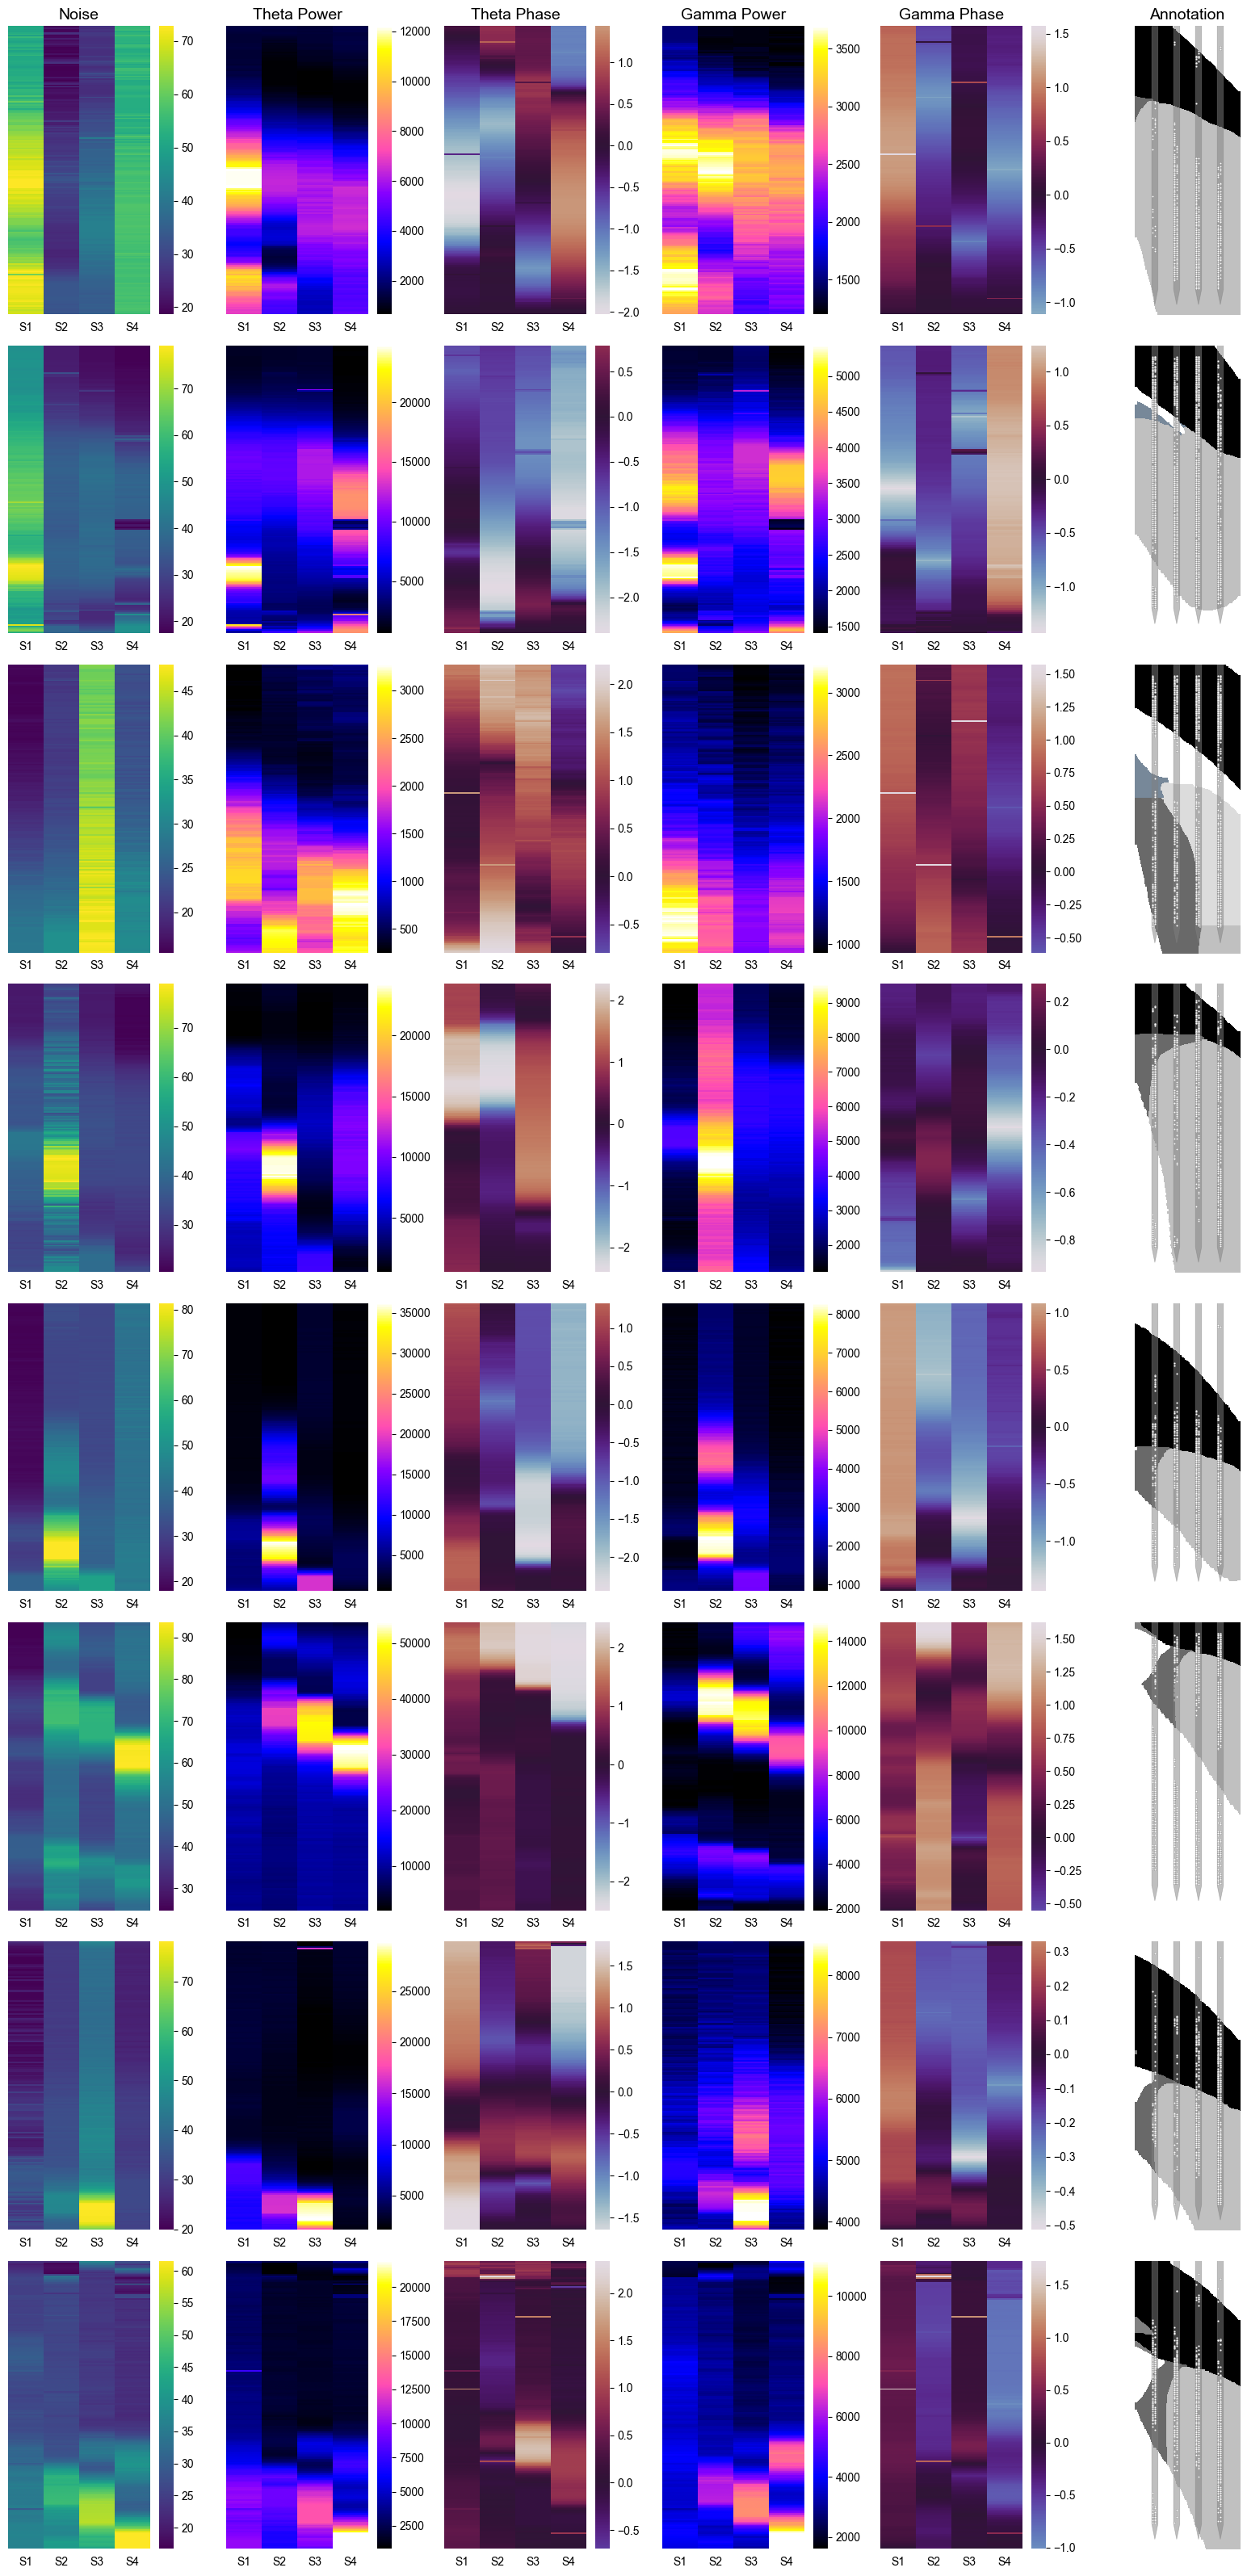

: 

In [ ]:
import seaborn as sns
from scipy.interpolate import interp1d

def interpolate_clipped(df, colname, day, perc_5, perc_95):
    mask = df['day'] == day
    vals = df.loc[mask, colname].values
    y_locs = df.loc[mask, 'y_loc'].values
    clipped = (vals < perc_5) | (vals > perc_95)
    vals_interp = vals.copy()
    if np.sum(~clipped) >= 2:
        interp_func = interp1d(
            y_locs[~clipped], vals[~clipped], kind='linear',
            bounds_error=False, fill_value="extrapolate"
        )
        vals_interp[clipped] = interp_func(y_locs[clipped])
    else:
        vals_interp[clipped] = np.nan
    df.loc[mask, colname] = np.clip(vals_interp, perc_5, perc_95)
    return df

mice = list(mouse_day_order.keys())
n_rows = len(mice)
n_cols = 6  # noise, theta_power, theta_phase, gamma_power, gamma_phase, annotation

col_titles = [
    "Noise", "Theta Power", "Theta Phase", "Gamma Power", "Gamma Phase", "Annotation"
]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows), squeeze=False, width_ratios=[1,1,1,1,1,1])

for row_idx, mouse in enumerate(mice):
    print(f'Processing mouse {mouse}')
    days = mouse_day_order[mouse]
    # Add mouse title at the start of each row
    axes[row_idx, 0].set_ylabel(f"Mouse {mouse}", fontsize=14, rotation=0, labelpad=60, va='center')
    # Heatmaps
    for col_idx, (df, title, colname, cmap, center) in enumerate([
        (noise, 'Noise', 'noise_level', 'viridis', None),
        (theta_power, 'Theta Power', 'theta_power', 'gnuplot2', None),
        (theta_phase, 'Theta Phase', 'theta_phase', 'twilight', 0),
        (gamma_power, 'Gamma Power', 'gamma_power', 'gnuplot2', None),
        (gamma_phase, 'Gamma Phase', 'gamma_phase', 'twilight', 0)
    ]):
        df_mouse = df[(df['mouse'] == mouse) & (df['day'].isin(days))].copy()
        if colname in ['theta_phase', 'gamma_phase']:
            heatmap_data = df_mouse.pivot_table(index='y_loc', columns='day', values=colname)
            heatmap_data = heatmap_data.reindex(columns=days)
            heatmap_data = heatmap_data.sort_index(ascending=True)
            sns.heatmap(
                heatmap_data, ax=axes[row_idx, col_idx], cmap=cmap, cbar=True, center=center,
                xticklabels=False, yticklabels=False
            )
        else:
            for day in days:
                mask = df_mouse['day'] == day
                perc_95 = df_mouse.loc[mask, colname].quantile(0.95)
                perc_5 = df_mouse.loc[mask, colname].quantile(0.05)
                df_mouse = interpolate_clipped(df_mouse, colname, day, perc_5, perc_95)
            heatmap_data = df_mouse.pivot_table(index='y_loc', columns='day', values=colname)
            heatmap_data = heatmap_data.reindex(columns=days)
            heatmap_data = heatmap_data.sort_index(ascending=True)
            sns.heatmap(
                heatmap_data, ax=axes[row_idx, col_idx], cmap=cmap, cbar=True,
                xticklabels=False, yticklabels=False
            )
        axes[row_idx, col_idx].set_xlabel('')
        axes[row_idx, col_idx].set_ylabel('')
        axes[row_idx, col_idx].set_ylim(axes[row_idx, col_idx].get_ylim()[::-1])
        axes[row_idx, col_idx].tick_params(
            axis='both', which='both', bottom=False, top=False, left=False, right=False
        )
        axes[row_idx, col_idx].set_xticks(np.arange(len(days)) + 0.5)
        axes[row_idx, col_idx].set_xticklabels(['S1', 'S2', 'S3', 'S4'])

    # Annotation plot in probe space (unique for each mouse)
    Mouse = f'M{mouse}'
    data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
    shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
    clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
    clusters_df = clusters_df[clusters_df['mouse'] == mouse]
    shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
    clusters_df = reconstruct_shank_id(clusters_df, mouse)
    probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
    adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
    adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)

    ymin = -300; ymax = 3000
    xmin = -200; xmax = 1000
    xs = np.arange(xmin, xmax, 1)
    ys = np.arange(ymin, ymax, 1)

    annotations_probe = np.zeros((len(ys), len(xs)), dtype=object)
    for yi, y in enumerate(ys):
        for xi, x in enumerate(xs):
            coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
            z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
            annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
            if len(structure_set[structure_set['id'] == annotation_index]) == 1:
                annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
            else:
                annotation = 'root'
            annotations_probe[yi, xi] = annotation

    annotation_colors = get_annotation_colors_2D(annotations_probe)

    ax_ann = axes[row_idx, 5]
    unique_colors = np.unique(annotation_colors)
    for color in unique_colors:
        border_points = extract_border(annotation_colors, color, only_border=False)
        x_points = xs[border_points[:, 1]]
        y_points = ys[border_points[:, 0]]
        ax_ann.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
    plot_NP2_probe(ax_ann, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                   probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
    ax_ann.scatter(all_by_anatomy[all_by_anatomy['mouse'] == mouse]['probe_x'], 
                   all_by_anatomy[all_by_anatomy['mouse'] == mouse]['probe_y'], 
                   color='white', marker='o', edgecolor='black', linewidth=0.1, s=3, rasterized=True)
    ax_ann.set_xlabel('')
    ax_ann.set_ylabel('')
    ax_ann.set_xlim(xs[0], xs[-1])
    ax_ann.set_ylim(ys[0], ys[-1])
    ax_ann.set_yticklabels([])
    ax_ann.set_xticklabels([])
    ax_ann.tick_params(
        axis='both', which='both', bottom=False, top=False, left=False, right=False
    )

# Set column titles
for col_idx, col_title in enumerate(col_titles):
    axes[0, col_idx].set_title(col_title, fontsize=14)

plt.tight_layout()
plt.savefig("/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_1_registration/cells_on_probe_validation.pdf", bbox_inches='tight')
plt.show()